# Class 11: Medical Image Segmentation
## Exploring Traditional Methods

**AI in Medicine and Healthcare**  
**Prof. Dr. Marcel P. Jackowski**  
**Insper - 2026**

---

## Student Information

**Student 1:** Rodrigo Medeiros

**Student 2:** Gabriel Hermida

---

## Lab Objectives

Today we'll explore **classical segmentation methods**:

1. **Thresholding** (manual and automatic)
2. **Region Growing** (seed-based)
3. **Edge Detection** (Sobel, LoG)
4. **Watershed Segmentation**

### Why Classical Methods First?

**Today:** Understand the challenges and limitations  
**Next Week:** See how U-Net (deep learning) solves these problems!

---

# Setup & Data Loading

In [1]:
# Install required packages (Colab)
!pip install -q scikit-image opencv-python-headless matplotlib numpy scipy

print('✓ Packages installed!')

✓ Packages installed!


In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, feature, measure, morphology, segmentation
from skimage.filters import threshold_otsu, threshold_multiotsu
from scipy import ndimage
import cv2
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
%matplotlib inline

print('✓ Libraries imported successfully!')
print(f'NumPy version: {np.__version__}')

✓ Libraries imported successfully!
NumPy version: 2.0.2


### Create Synthetic Medical Image

Let's generate a synthetic medical image:

Using synthetic brain image


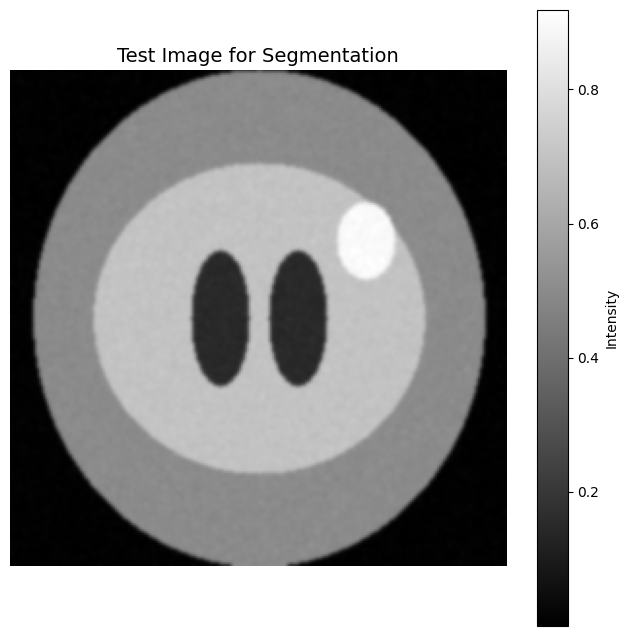

In [3]:
def create_synthetic_brain(size=256):
    """
    Create a synthetic brain MRI with tumor.
    """
    image = np.zeros((size, size))

    # Brain outline (ellipse)
    y, x = np.ogrid[:size, :size]
    center = size // 2
    brain_mask = ((x - center)**2 / (size/2.2)**2 + (y - center)**2 / (size/2)**2) <= 1

    # Gray matter (intermediate intensity)
    image[brain_mask] = 0.5

    # White matter (higher intensity, inner region)
    white_matter = ((x - center)**2 / (size/3)**2 + (y - center)**2 / (size/3.2)**2) <= 1
    image[white_matter] = 0.7

    # Add ventricles (dark, CSF)
    ventricle1 = ((x - center+20)**2 / 15**2 + (y - center)**2 / 35**2) <= 1
    ventricle2 = ((x - center-20)**2 / 15**2 + (y - center)**2 / 35**2) <= 1
    image[ventricle1 | ventricle2] = 0.15

    # Add tumor (bright region)
    tumor = ((x - center-55)**2 / 15**2 + (y - center+40)**2 / 20**2) <= 1
    image[tumor] = 0.9

    # Add realistic noise
    noise = np.random.normal(0, 0.02, (size, size))
    image = np.clip(image + noise, 0, 1)

    # Smooth slightly
    image = ndimage.gaussian_filter(image, sigma=1.0)

    return image

# Generate synthetic image as backup
synthetic_brain = create_synthetic_brain(256)

# Use synthetic if download failed
try:
    test_image = brain_gray
except:
    test_image = synthetic_brain
    print('Using synthetic brain image')

# Visualize
plt.figure(figsize=(8, 8))
plt.imshow(test_image, cmap='gray')
plt.title('Test Image for Segmentation', fontsize=14)
plt.axis('off')
plt.colorbar(label='Intensity')
plt.show()

## Histogram Analysis

Before segmentation, let's analyze the intensity distribution:

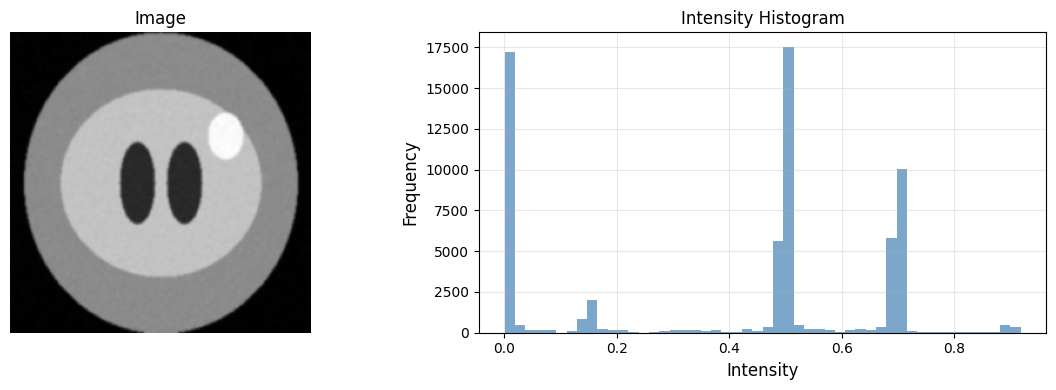

💡 Notice: Multiple peaks suggest different tissue types!
   - Low intensity: CSF (cerebrospinal fluid)
   - Medium: Gray matter
   - High: White matter, tumor


In [4]:
# Plot histogram
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(test_image, cmap='gray')
plt.title('Image', fontsize=12)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(test_image.ravel(), bins=50, color='steelblue', alpha=0.7)
plt.xlabel('Intensity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Intensity Histogram', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('💡 Notice: Multiple peaks suggest different tissue types!')
print('   - Low intensity: CSF (cerebrospinal fluid)')
print('   - Medium: Gray matter')
print('   - High: White matter, tumor')

---

# PART 1: Thresholding Methods

**Thresholding function:**

$$g(x) = \begin{cases} 1 & \text{if } I(x) \geq T \\\\ 0 & \text{if } I(x) < T \end{cases}$$

**Challenge:** How to choose threshold $T$?

---

## Step 1.1: Manual Thresholding

**TODO:** Implement and experiment with different thresholds

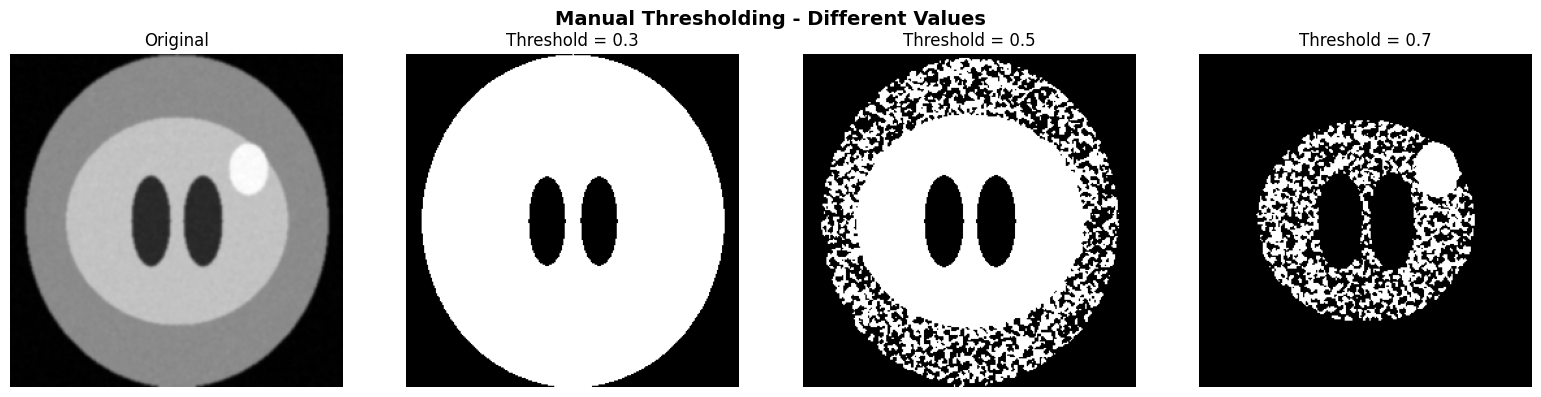

❓ Question: Which threshold works best?
T≈0.5 for white matter, T≈0.7 for the tumor.


In [16]:
def manual_threshold(image, threshold):
    """
    Apply manual threshold to image.

    Parameters:
    -----------
    image : 2D array
        Input grayscale image
    threshold : float
        Threshold value (0-1 for normalized images)

    Returns:
    --------
    binary : 2D array
        Binary segmentation mask
    """
    binary = image >= threshold

    return binary

# Test with different thresholds
thresholds = [0.3, 0.5, 0.7]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original
axes[0].imshow(test_image, cmap='gray')
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

# Different thresholds
for i, thresh in enumerate(thresholds):
    binary = manual_threshold(test_image, thresh)
    axes[i+1].imshow(binary, cmap='gray')
    axes[i+1].set_title(f'Threshold = {thresh}', fontsize=12)
    axes[i+1].axis('off')

plt.suptitle('Manual Thresholding - Different Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('❓ Question: Which threshold works best?')
print('T≈0.5 for white matter, T≈0.7 for the tumor.')

## Step 1.2: Otsu's Automatic Thresholding

**Otsu's method** automatically finds optimal threshold by maximizing between-class variance.

**TODO:** Apply Otsu's method

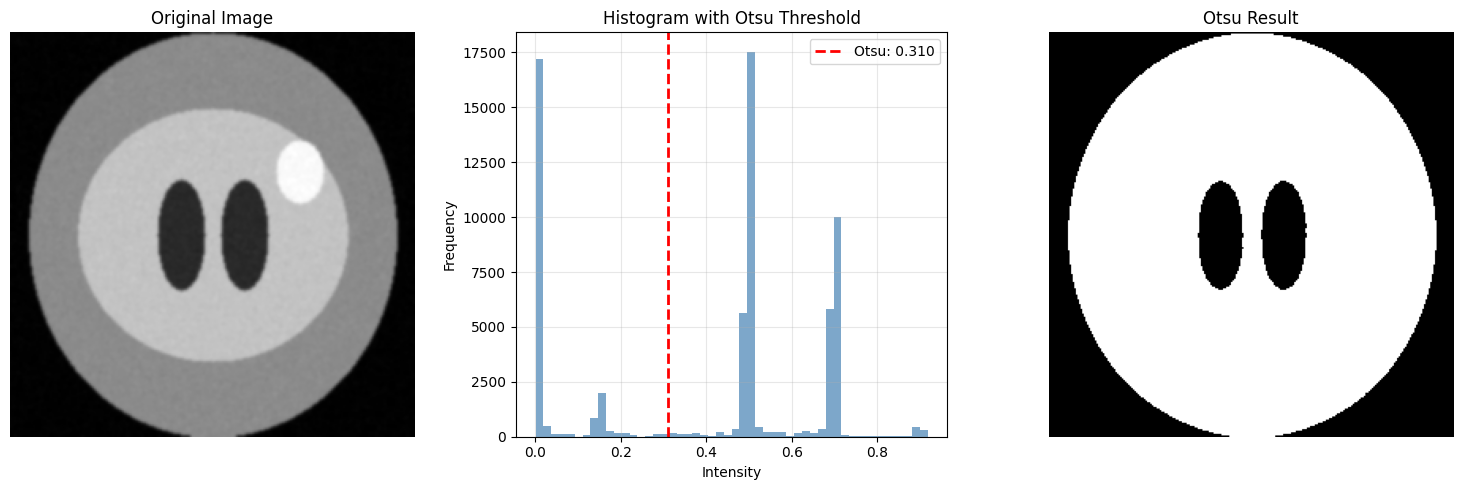

✓ Otsu threshold: 0.310


In [6]:
# Apply Otsu's method
otsu_thresh = threshold_otsu(test_image)

# Apply threshold
binary_otsu = test_image >= otsu_thresh

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
axes[0].imshow(test_image, cmap='gray')
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')

# Histogram with threshold line
axes[1].hist(test_image.ravel(), bins=50, color='steelblue', alpha=0.7)
if otsu_thresh is not None:
    axes[1].axvline(otsu_thresh, color='red', linewidth=2, linestyle='--', label=f'Otsu: {otsu_thresh:.3f}')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram with Otsu Threshold', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Binary result
if binary_otsu is not None:
    axes[2].imshow(binary_otsu, cmap='gray')
axes[2].set_title('Otsu Result', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f'✓ Otsu threshold: {otsu_thresh:.3f}')

## Step 1.3: Multi-Level Thresholding

For multiple tissue types, we need multiple thresholds.

**TODO:** Apply multi-level Otsu

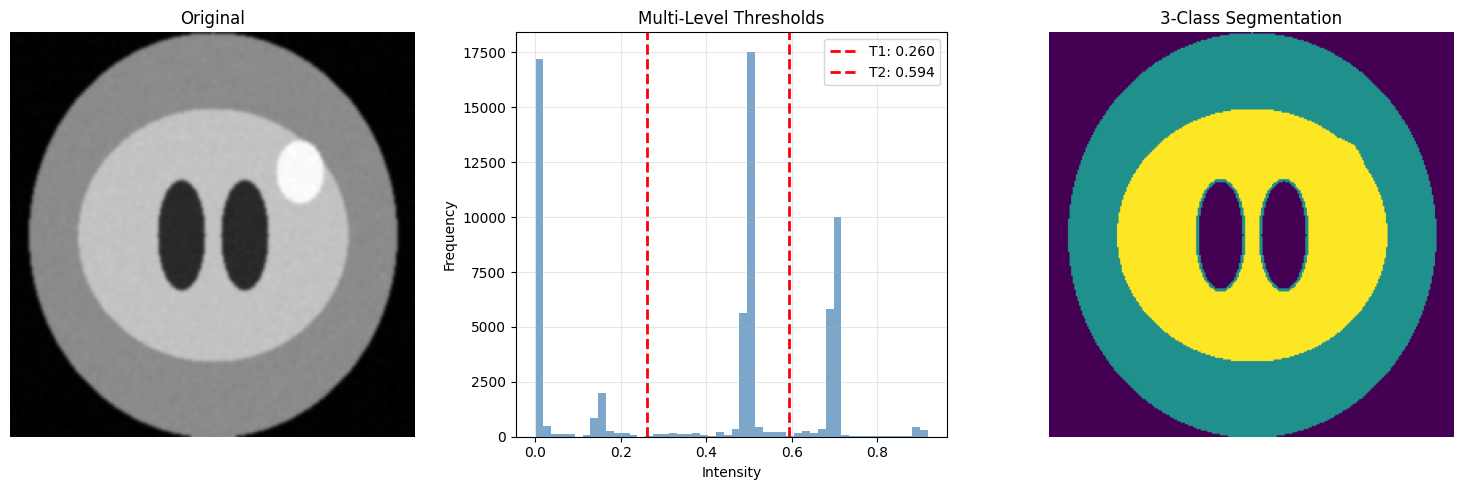

✓ Multi-level segmentation:
  Class 0: Low intensity (CSF)
  Class 1: Medium (Gray matter)
  Class 2: High (White matter, tumor)


In [7]:
# Multi-level Otsu (3 classes)
multi_thresh = threshold_multiotsu(test_image, classes=3)

# Create multi-level segmentation
if multi_thresh is not None:
    regions = np.digitize(test_image, bins=multi_thresh)
else:
    regions = np.zeros_like(test_image)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(test_image, cmap='gray')
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

axes[1].hist(test_image.ravel(), bins=50, color='steelblue', alpha=0.7)
if multi_thresh is not None:
    for i, t in enumerate(multi_thresh):
        axes[1].axvline(t, color='red', linewidth=2, linestyle='--', label=f'T{i+1}: {t:.3f}')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Multi-Level Thresholds', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].imshow(regions, cmap='viridis')
axes[2].set_title('3-Class Segmentation', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print('✓ Multi-level segmentation:')
print('  Class 0: Low intensity (CSF)')
print('  Class 1: Medium (Gray matter)')
print('  Class 2: High (White matter, tumor)')

---

# PART 2: Region Growing & Watershed

**Region Growing:**
1. Start with seed points
2. Iteratively add similar neighboring pixels
3. Stop when no more pixels match criteria

---

## Step 2.1: Region Growing

**TODO:** Experiment with multiple threshold values and seed point placements !

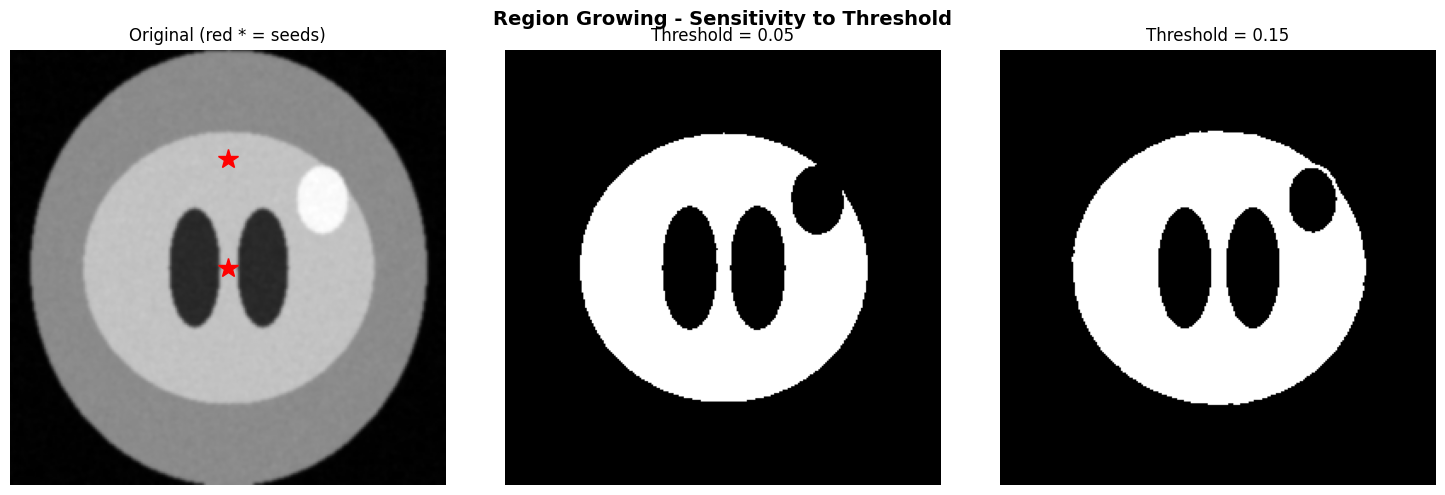

In [8]:
def region_growing(image, seed, threshold=0.1):
    """
    Region growing segmentation.

    Parameters:
    -----------
    image : 2D array
        Input image
    seed : tuple (y, x)
        Starting seed point
    threshold : float
        Maximum intensity difference for inclusion

    Returns:
    --------
    segmented : 2D array
        Binary segmentation mask
    """
    # Steps:
    # 1. Create empty mask
    # 2. Get seed intensity
    # 3. Use queue to process neighbors
    # 4. Add pixels if intensity difference < threshold

    segmented = np.zeros_like(image, dtype=bool)

    # Simplified implementation provided
    from collections import deque

    h, w = image.shape
    seed_y, seed_x = seed
    seed_value = image[seed_y, seed_x]

    queue = deque([seed])
    segmented[seed_y, seed_x] = True

    while queue:
        y, x = queue.popleft()

        # Check 4-connected neighbors
        for dy, dx in [(-1,0), (1,0), (0,-1), (0,1)]:
            ny, nx = y + dy, x + dx

            # Check bounds
            if 0 <= ny < h and 0 <= nx < w:
                # Check if not visited and similar intensity
                if not segmented[ny, nx]:
                    if abs(image[ny, nx] - seed_value) < threshold:
                        segmented[ny, nx] = True
                        queue.append((ny, nx))

    return segmented

# TO DO:
# Test with different seeds and thresholds
seeds = [
    (test_image.shape[0]//2, test_image.shape[1]//2),  # Center
    (test_image.shape[0]//4, test_image.shape[1]//2),  # Top
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original with seed points
axes[0].imshow(test_image, cmap='gray')
for seed in seeds:
    axes[0].plot(seed[1], seed[0], 'r*', markersize=15)
axes[0].set_title('Original (red * = seeds)', fontsize=12)
axes[0].axis('off')

# Region growing with different thresholds
thresholds = [0.05, 0.15]
for i, thresh in enumerate(thresholds):
    result = region_growing(test_image, seeds[0], threshold=thresh)
    axes[i+1].imshow(result, cmap='gray')
    axes[i+1].set_title(f'Threshold = {thresh}', fontsize=12)
    axes[i+1].axis('off')

plt.suptitle('Region Growing - Sensitivity to Threshold', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 2.2: Watershed Segmentation

**Watershed** treats the image as a topographic surface.

**TODO:** Apply watershed segmentation. Can you make it better (+1 Extra point)?

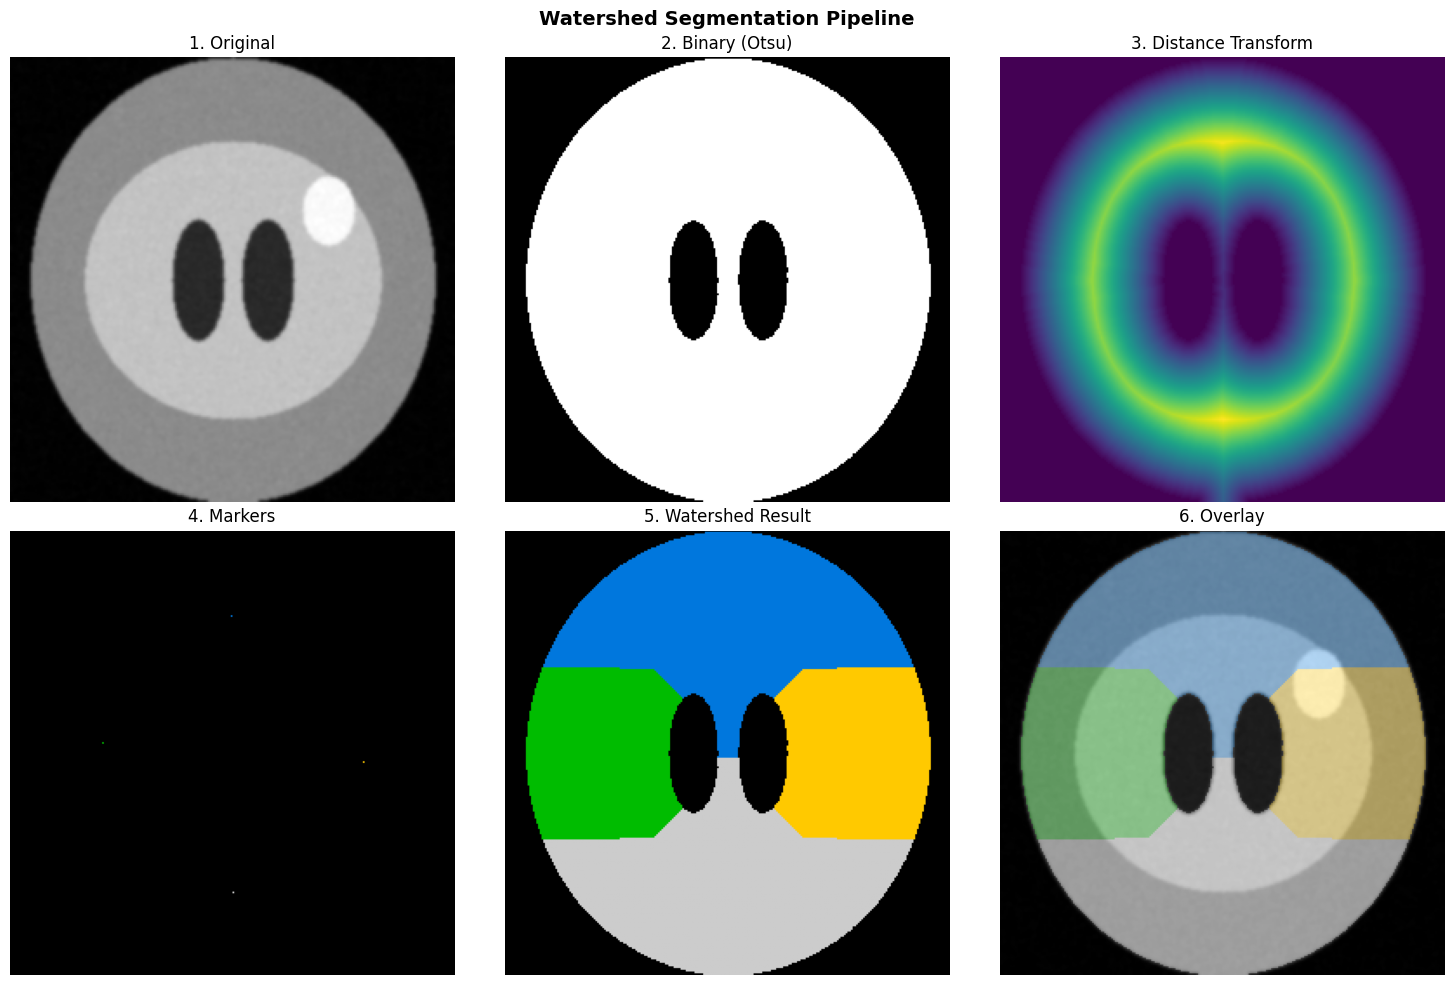

✓ Found 4 regions


In [9]:
# Prepare for watershed
# Step 1: Create binary mask (use Otsu)
binary = test_image > threshold_otsu(test_image)

# Step 2: Distance transform
distance = ndimage.distance_transform_edt(binary)

# Step 3: Find local maxima as markers
from skimage.feature import peak_local_max
coords = peak_local_max(distance, min_distance=20, labels=binary)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndimage.label(mask)

# Step 4: Apply watershed
labels = segmentation.watershed(-distance, markers, mask=binary)

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(test_image, cmap='gray')
axes[0, 0].set_title('1. Original', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(binary, cmap='gray')
axes[0, 1].set_title('2. Binary (Otsu)', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(distance, cmap='viridis')
axes[0, 2].set_title('3. Distance Transform', fontsize=12)
axes[0, 2].axis('off')

axes[1, 0].imshow(markers, cmap='nipy_spectral')
axes[1, 0].set_title('4. Markers', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(labels, cmap='nipy_spectral')
axes[1, 1].set_title('5. Watershed Result', fontsize=12)
axes[1, 1].axis('off')

# Overlay
axes[1, 2].imshow(test_image, cmap='gray')
axes[1, 2].imshow(labels, cmap='nipy_spectral', alpha=0.3)
axes[1, 2].set_title('6. Overlay', fontsize=12)
axes[1, 2].axis('off')

plt.suptitle('Watershed Segmentation Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'✓ Found {labels.max()} regions')


---

# PART 3: Edge Detection

**Edge Detection** finds boundaries between regions.

**Two approaches:**
1. **Gradient-based:** Sobel, Canny (first derivative)
2. **Zero-crossing:** LoG (second derivative)

**Challenge:** Edges are often disconnected!

---

## Step 3.1: Sobel Edge Detection

**Sobel** computes image gradient magnitude.

**TODO:** Apply Sobel filter

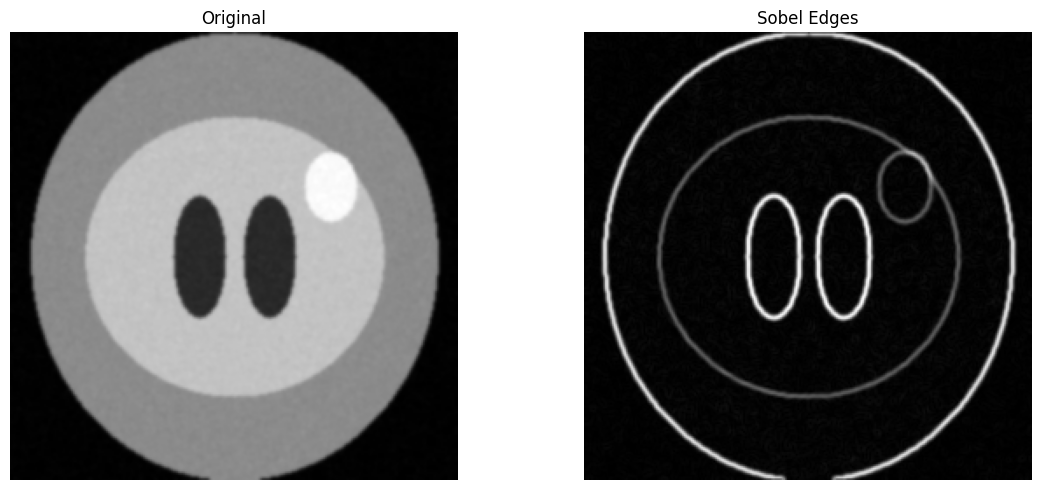

💡 Sobel detects intensity changes (gradients)


In [10]:
# Apply Sobel filter
edges_sobel = filters.sobel(test_image)


# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(test_image, cmap='gray')
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

if edges_sobel is not None:
    axes[1].imshow(edges_sobel, cmap='gray')
axes[1].set_title('Sobel Edges', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print('💡 Sobel detects intensity changes (gradients)')

## Step 3.2: Laplacian of Gaussian (LoG)

**LoG** finds zero-crossings in the second derivative.

**TODO:** Apply LoG edge detection

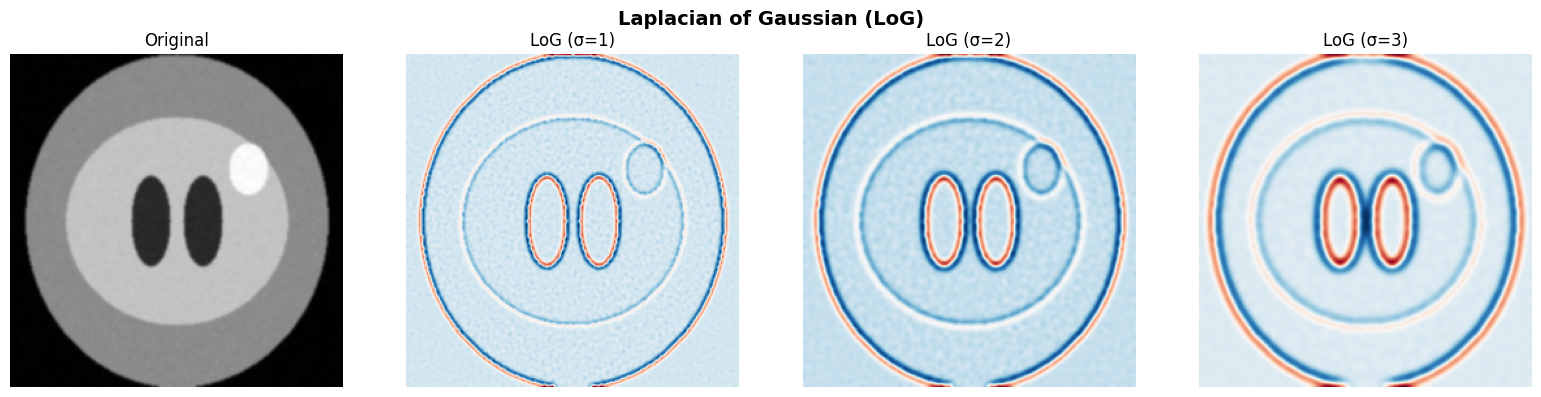

💡 LoG: Red = positive, Blue = negative
   Zero-crossings (boundary between red/blue) = edges


In [11]:
# Apply Laplacian of Gaussian
# Step 1: Smooth with Gaussian
# Step 2: Apply Laplacian

from scipy.ndimage import gaussian_laplace

# Calculate LoG for different sigma values
edges_log1 = gaussian_laplace(test_image, sigma=1)
edges_log2 = gaussian_laplace(test_image, sigma=2)
edges_log3 = gaussian_laplace(test_image, sigma=3)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(test_image, cmap='gray')
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

axes[1].imshow(edges_log1, cmap='RdBu_r')
axes[1].set_title('LoG (σ=1)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(edges_log2, cmap='RdBu_r')
axes[2].set_title('LoG (σ=2)', fontsize=12)
axes[2].axis('off')

axes[3].imshow(edges_log3, cmap='RdBu_r')
axes[3].set_title('LoG (σ=3)', fontsize=12)
axes[3].axis('off')

plt.suptitle('Laplacian of Gaussian (LoG)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 LoG: Red = positive, Blue = negative')
print('   Zero-crossings (boundary between red/blue) = edges')

---

# PART 4: Comparison & Discussion

Let's compare all methods side-by-side!


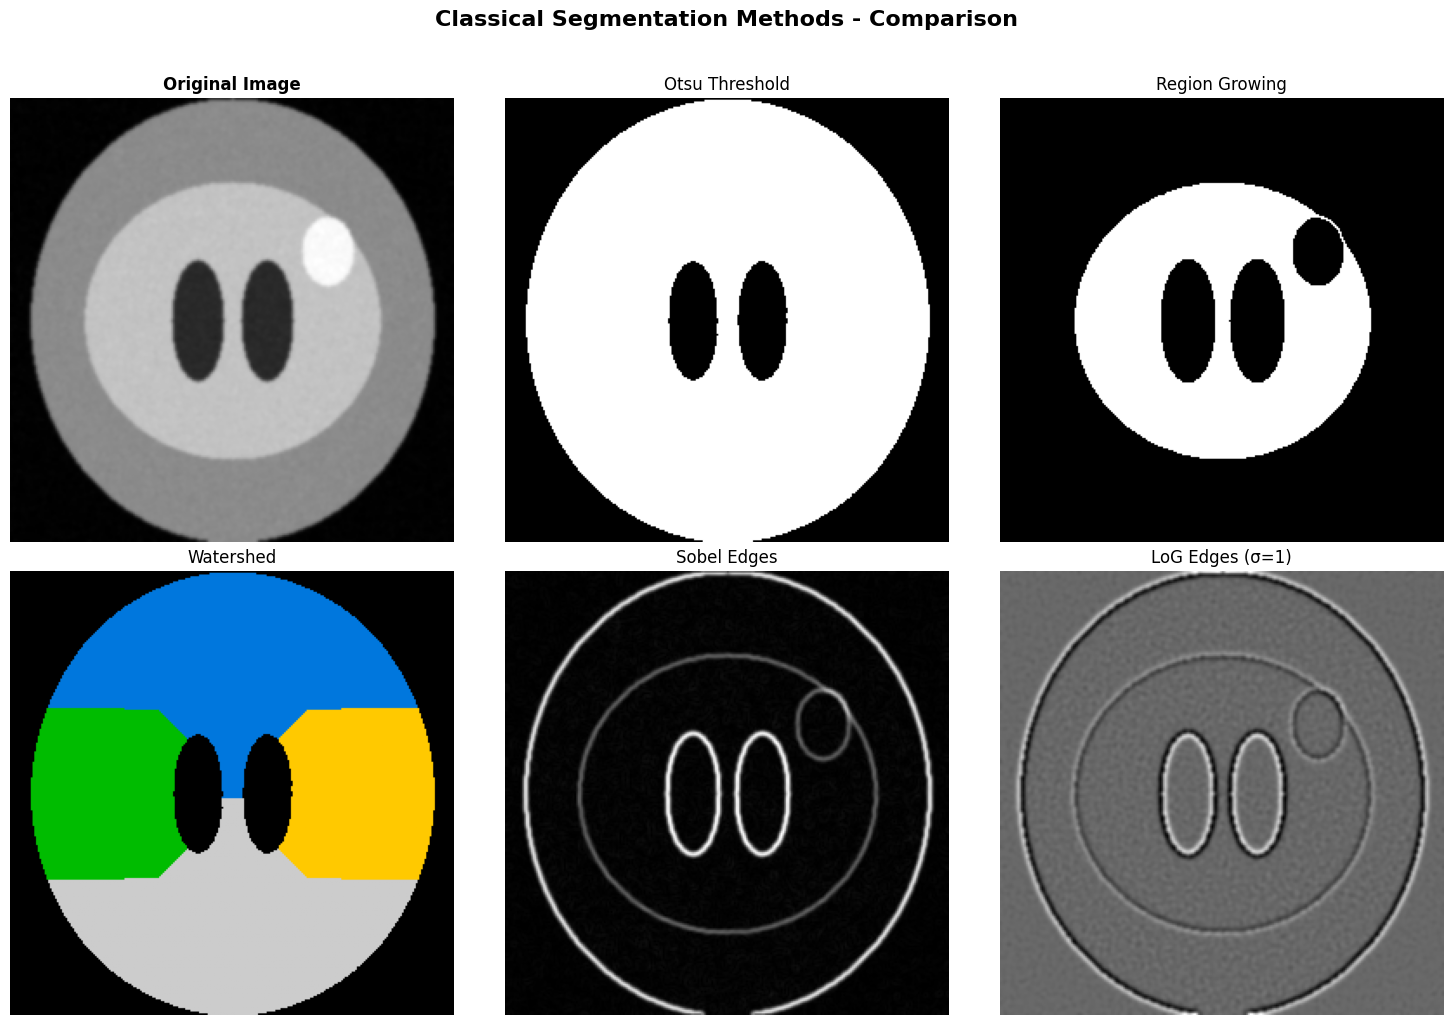

In [12]:
# Generate results from all methods
binary_thresh = test_image > threshold_otsu(test_image)
region_result = region_growing(test_image, (test_image.shape[0]//2, test_image.shape[1]//2), 0.1)
edges_sobel_result = filters.sobel(test_image)
edges_log_result = gaussian_laplace(test_image, sigma=1)

# Create comprehensive comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(test_image, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(binary_thresh, cmap='gray')
axes[0, 1].set_title('Otsu Threshold', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(region_result, cmap='gray')
axes[0, 2].set_title('Region Growing', fontsize=12)
axes[0, 2].axis('off')

axes[1, 0].imshow(labels, cmap='nipy_spectral')
axes[1, 0].set_title('Watershed', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(edges_sobel_result, cmap='gray')
axes[1, 1].set_title('Sobel Edges', fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(edges_log_result, cmap='gray')
axes[1, 2].set_title('LoG Edges (σ=1)', fontsize=12)
axes[1, 2].axis('off')

plt.suptitle('Classical Segmentation Methods - Comparison',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Final Discussion Questions

**1. Count the parameters you had to manually tune today:**

**Your count:** At least 10+ parameters — manual threshold values (0.3, 0.5, 0.7), Otsu number of classes, region-growing seed coordinates and intensity threshold, watershed `min_distance` for peak detection, Gaussian smoothing sigma, LoG sigmas (1, 2, 3), morphological structuring elements, and the choice of connectivity (4 vs 8) in region growing.

**2. Were the methods sensitive to noise?**

**Your answer:** Yes, very. Edge detectors (Sobel, LoG) amplify noise directly since they rely on derivatives — that's why we smooth with Gaussian first. Thresholding misclassifies noisy pixels near the threshold boundary, creating salt-and-pepper artifacts. Region growing can "leak" through noisy pixels that happen to fall within the tolerance, and watershed typically over-segments because every noise-induced local minimum becomes its own basin.

**3. What was the most frustrating part of these methods?**

**Your answer:** The constant manual parameter tuning. Every image needs different thresholds, seeds, and sigmas, and there's no principled way to pick them — it's trial-and-error. Small parameter changes produce drastically different results, and a setting that works on one slice can fail on the next. There is also no notion of semantic understanding: the algorithm doesn't know what a "tumor" is, only intensity statistics.

**4. How would these methods work on 1000 different patients?**

**Your answer:** Poorly without per-patient tuning. Intensity distributions vary with scanner, acquisition protocol, contrast, patient anatomy, and pathology, so a single threshold or seed strategy won't generalize. You'd need either a human in the loop for each case or elaborate preprocessing (bias-field correction, intensity normalization, registration), and even then results would be inconsistent. It does not scale.

**5. What would an ideal segmentation method do automatically?**

**Your answer:** It would learn what each anatomical structure looks like from examples — handling noise, intensity variation, and shape variability without manual parameters. It would be robust across scanners and patients, produce semantically meaningful labels (not just intensity clusters), require no per-image tuning, and quantify its own uncertainty. This is exactly what deep learning approaches like U-Net provide: data-driven, end-to-end learned segmentation.
